In [1]:
# Librerías
import numpy as np
import pandas as pd
import shap
import seaborn as sns

from google.colab import drive

import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Cargamos el dataset
drive.mount("/content/drive")

df = pd.read_csv("/content/drive/MyDrive/ML/temps.csv")  # Modificar según ruta donde se almacene

print(df.head()) # Los datos cargaron correctamente

Mounted at /content/drive
   year  month  day  week  temp_2  temp_1  average  actual  forecast_noaa  \
0  2016      1    1   Fri      45      45     45.6      45             43   
1  2016      1    2   Sat      44      45     45.7      44             41   
2  2016      1    3   Sun      45      44     45.8      41             43   
3  2016      1    4   Mon      44      41     45.9      40             44   
4  2016      1    5  Tues      41      40     46.0      44             46   

   forecast_acc  forecast_under  friend  
0            50              44      29  
1            50              44      61  
2            46              47      56  
3            48              46      53  
4            46              46      41  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            348 non-null    int64  
 1   month           348 non-null    int64  
 2   day             348 non-null    int64  
 3   week            348 non-null    object 
 4   temp_2          348 non-null    int64  
 5   temp_1          348 non-null    int64  
 6   average         348 non-null    float64
 7   actual          348 non-null    int64  
 8   forecast_noaa   348 non-null    int64  
 9   forecast_acc    348 non-null    int64  
 10  forecast_under  348 non-null    int64  
 11  friend          348 non-null    int64  
dtypes: float64(1), int64(10), object(1)
memory usage: 32.8+ KB


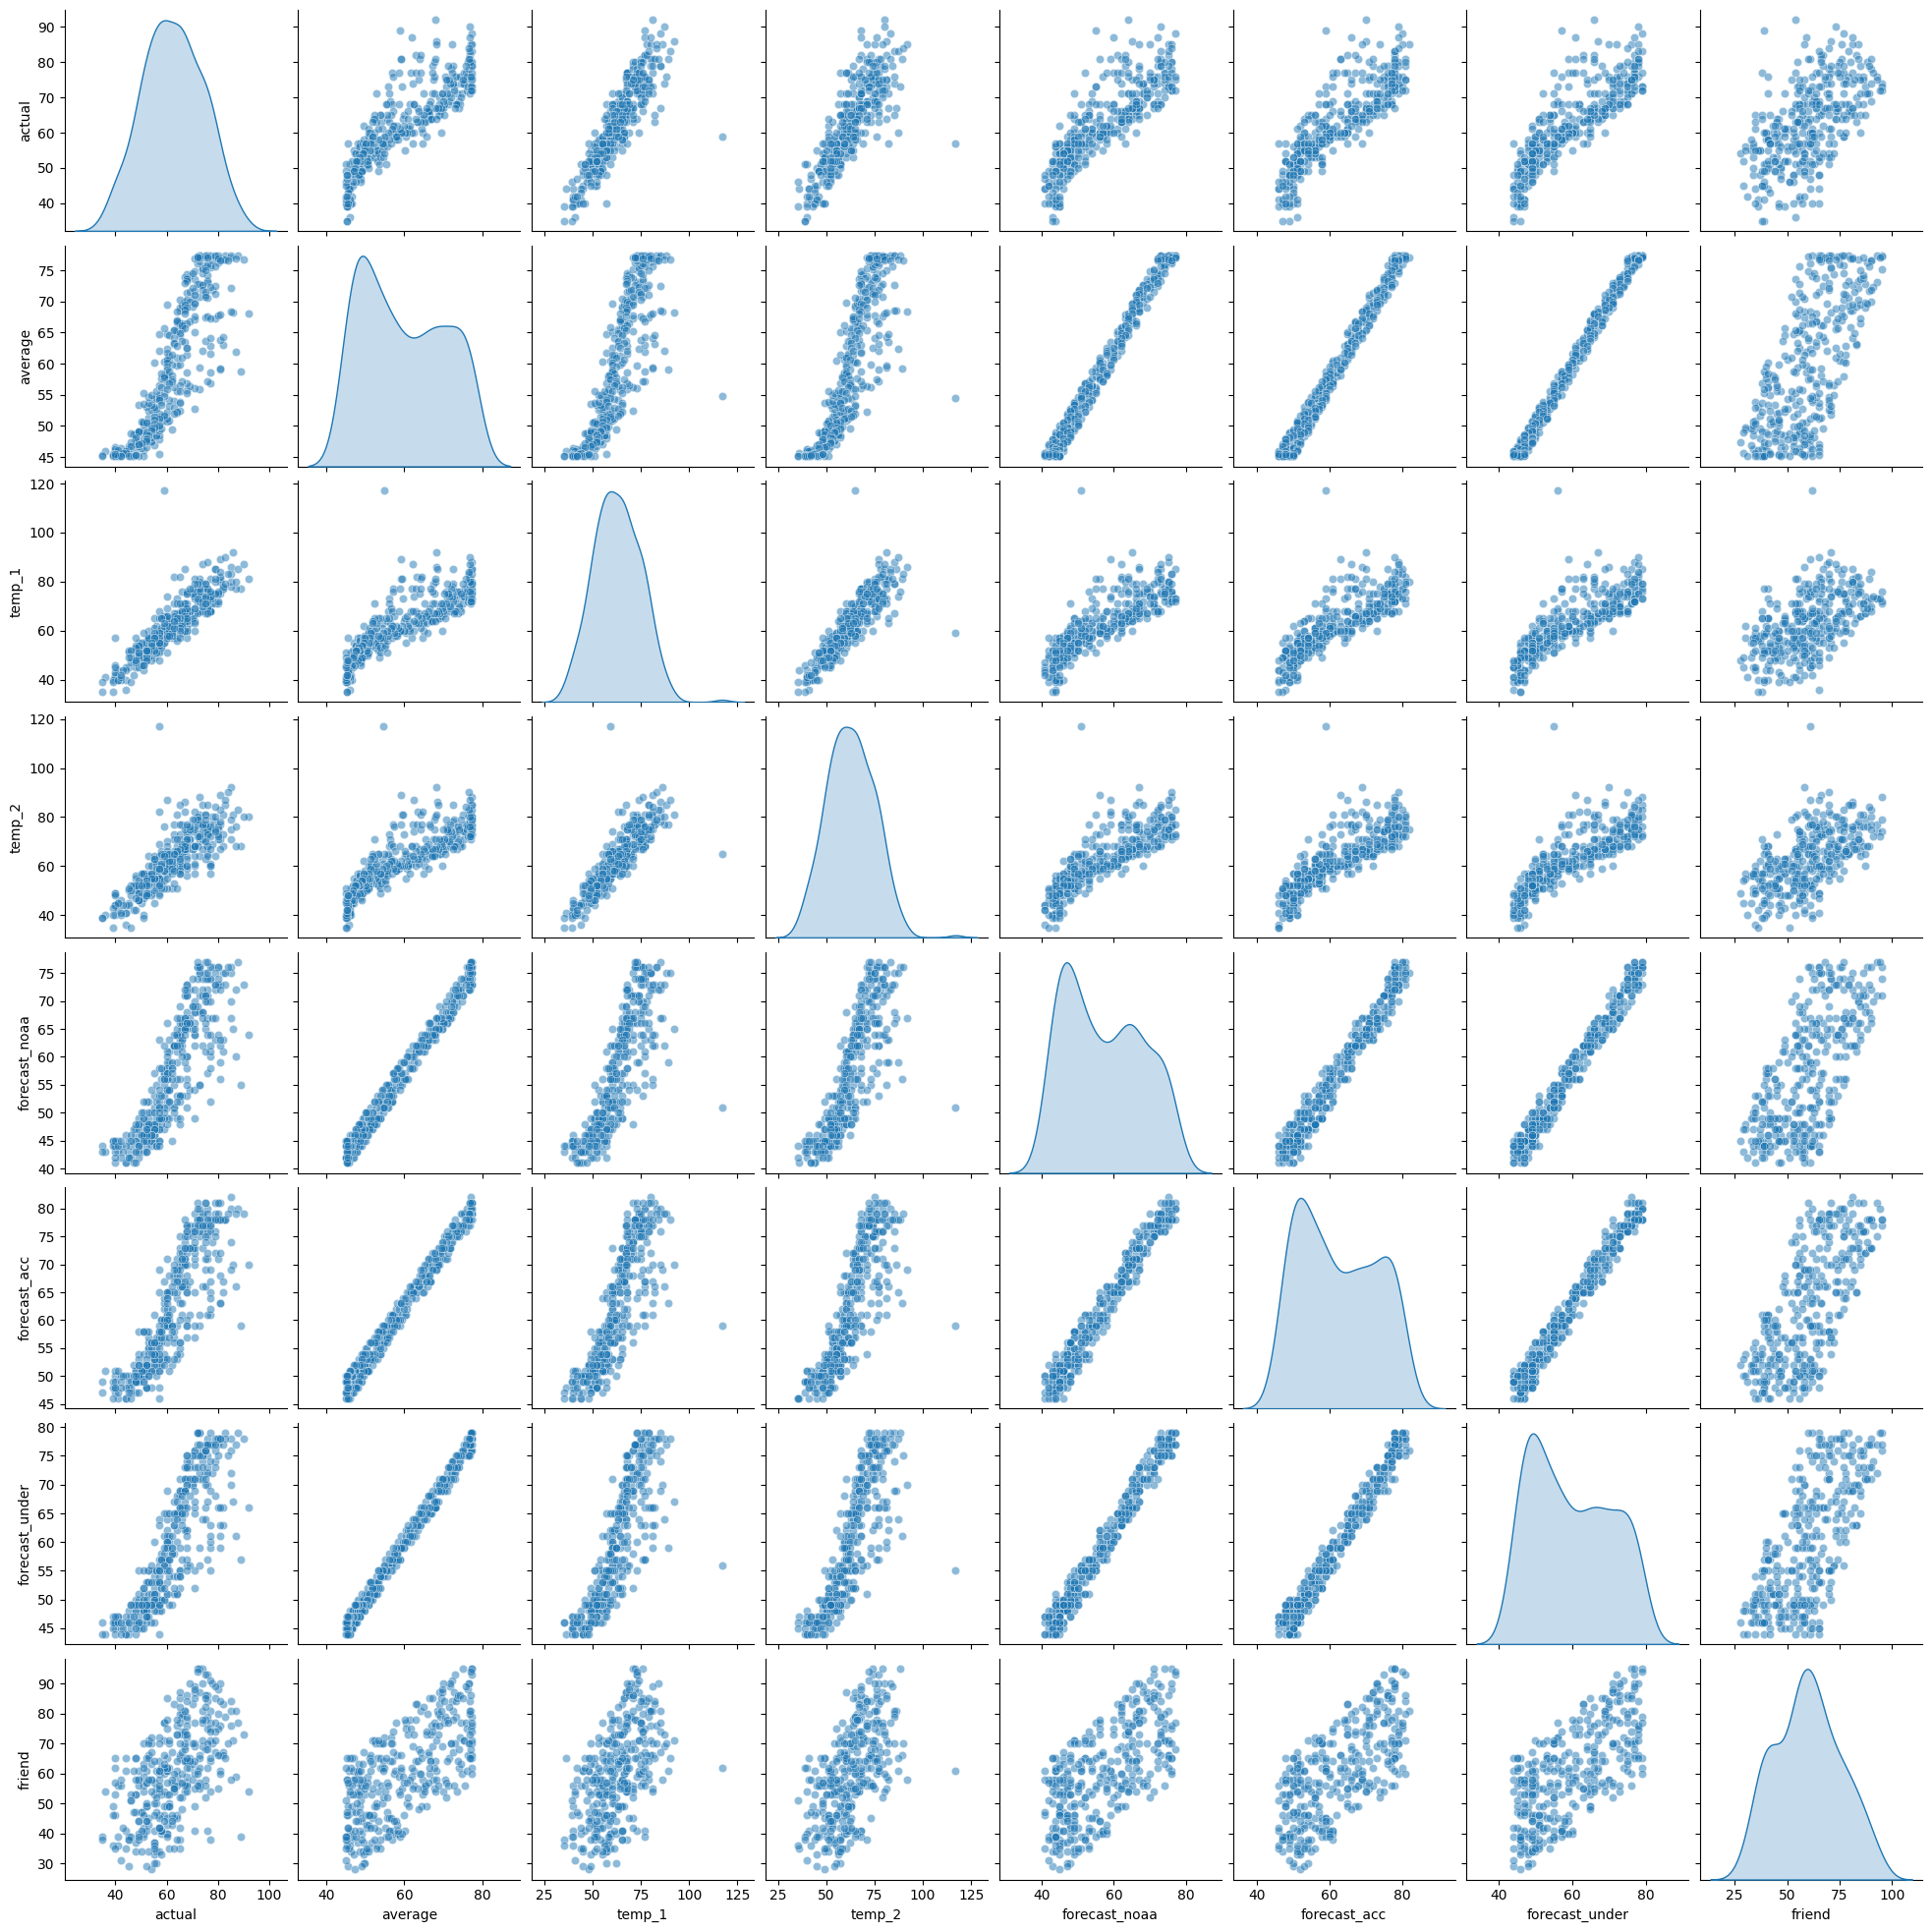

In [4]:
# Mostramos un grafico de dispersión
cols = ["actual", "average", "temp_1", "temp_2", "forecast_noaa", "forecast_acc", "forecast_under", "friend"]
sns.pairplot(df[cols], diag_kind="kde", plot_kws={"alpha": 0.5})
plt.show()

Observamos cierta tendencia lineal en la mayoria de variables.

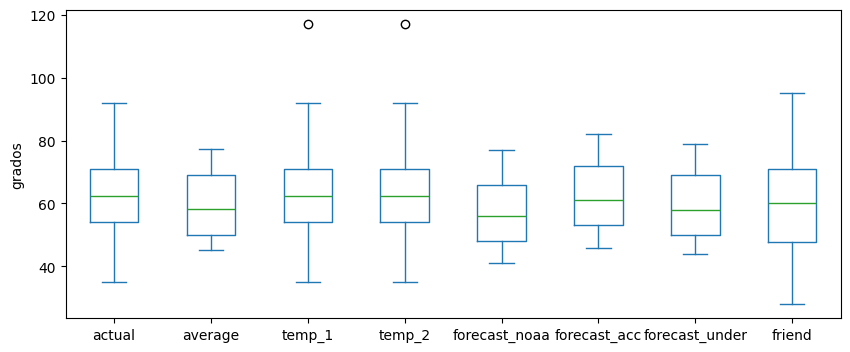

In [5]:
# Mostramos un boxplot
df[cols].plot.box(figsize=(10,4), ylabel="grados")
plt.show()

No hay prácticamente outliers y presentan escalas similares, y las variables actual, temp 1 y 2 y friend tienen cierta variabilidad.


In [6]:
# Convertimos en variables dummies los dias de la semana
df = pd.get_dummies(df, columns=["week"])
df

,year,month,day,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,week_Fri,week_Mon,week_Sat,week_Sun,week_Thurs,week_Tues,week_Wed
0,2016,1,1,45,45,45.6,45,43,50,44,29,True,False,False,False,False,False,False
1,2016,1,2,44,45,45.7,44,41,50,44,61,False,False,True,False,False,False,False
2,2016,1,3,45,44,45.8,41,43,46,47,56,False,False,False,True,False,False,False
3,2016,1,4,44,41,45.9,40,44,48,46,53,False,True,False,False,False,False,False
4,2016,1,5,41,40,46.0,44,46,46,46,41,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,2016,12,27,42,42,45.2,47,41,50,47,47,False,False,False,False,False,True,False
344,2016,12,28,42,47,45.3,48,41,49,44,58,False,False,False,False,False,False,True
345,2016,12,29,47,48,45.3,48,43,50,45,65,False,False,False,False,True,False,False
346,2016,12,30,48,48,45.4,57,44,46,44,42,True,False,False,False,False,False,False


In [7]:
# Separamos el data set en datos en entrenamiento y prueba.
X = df.drop("actual", axis=1)
y = df["actual"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [8]:
# Creamos el modelo y predecimos.
modelo = RandomForestRegressor()

param_grid = {
    "n_estimators": [25, 50, 100],
    "max_depth": [None, 20, 50],
    "min_samples_split": [2, 5, 7],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"],
    }

grid = GridSearchCV(modelo, param_grid, cv=5)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [None, 20, 50], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5, 7],
                         'n_estimators': [25, 50, 100]})

In [9]:
#Evaluamos el model
print("Mejores parámetros:", grid.best_params_)
print("Mejor precisión (CV):", grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))

Mejores parámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Mejor precisión (CV): 0.8242374550718937
MAE: 3.81
RMSE: 5.05
R²: 0.8175


El modelo explica una varianza del 81% e la temperatura.

In [10]:
# Calculamos la importancia
importancias = pd.Series(best_model.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)

print(importancias)

temp_1            0.284453
average           0.172789
forecast_acc      0.160224
forecast_noaa     0.115774
forecast_under    0.088009
temp_2            0.063260
month             0.045727
friend            0.031971
day               0.019693
week_Fri          0.003870
week_Sun          0.003073
week_Sat          0.002736
week_Mon          0.002511
week_Tues         0.002112
week_Wed          0.002071
week_Thurs        0.001728
year              0.000000
dtype: float64


Las variables con más peso son temp_1, average, forecast_acc     

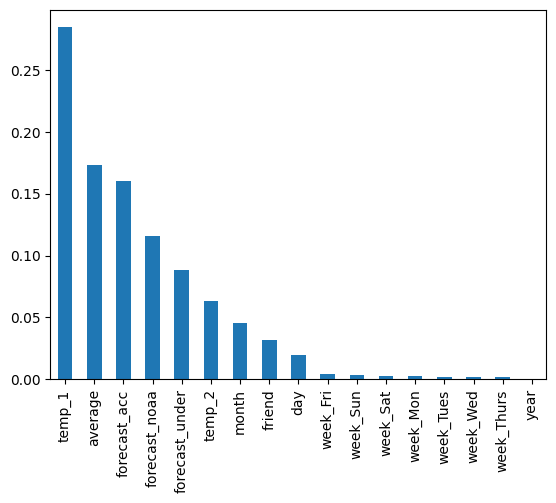

In [11]:
importancias.plot(kind="bar")
plt.show()

El algoritmo de árbol de decisión individual puede ser limitado, ya que tiende a memorizar los datos de entrenamiento, lo que genera overfitting. Random Forest, al combinar múltiples árboles, elimina este problema; esto sería por la aleatoriedad del entrenamiento, al entrenarse con diferentes muestras. Por otro lado, Random Forest pierde interpretabilidad al no generarse un árbol final, aunque se pueden usar técnicas para mejorar esta, como feature of importance.


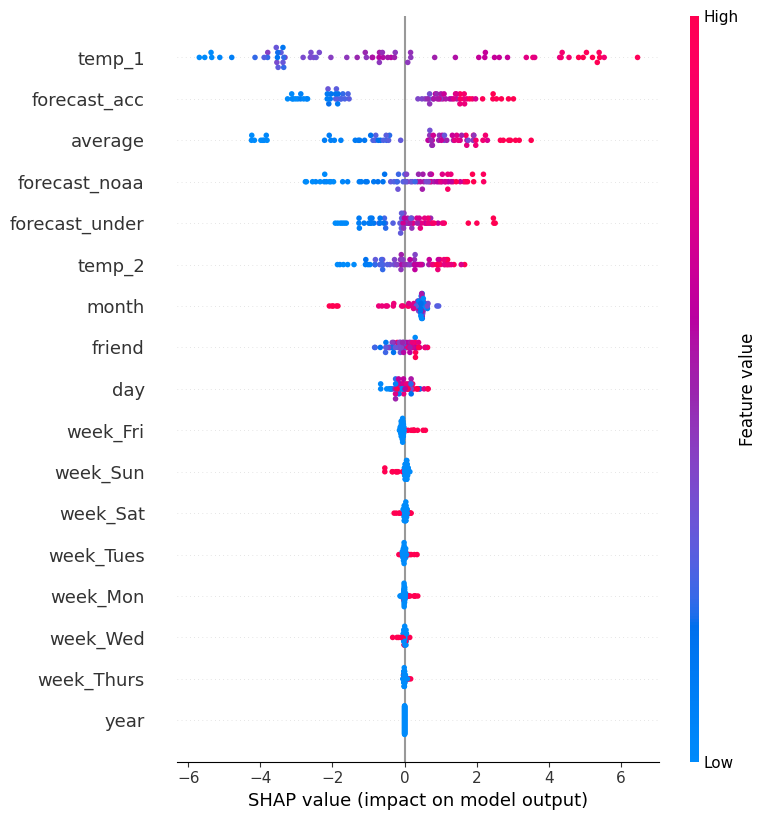

In [12]:
# SHAP
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

Para finalizar el ejercicio, realizamos SHAP, donde vemos, como era de esperar, que las temperaturas más altas hacen que el target suba y las más bajas que baje.

